# Three-Class Depression Severity Classification from Eyes-Closed EEG

This notebook trains and evaluates machine-learning models to classify participants into:

- Group 1: Minimal depression
- Group 2: Mild depression
- Group 3: Moderate depression

The model uses EEG-derived features only. Participant ID, gender, BDI-II, and PHQ-9 are excluded from the feature matrix.


 ============================================================
# 1. Import libraries and configure the modeling experiment
# ============================================================


In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV , StratifiedKFold
from sklearn.model_selection import cross_validate , RepeatedStratifiedKFold

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest ,f_classif 


from sklearn.ensemble import  ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score, 
    recall_score,
    f1_score, 
    classification_report, 
    confusion_matrix
)

RANDOM_STATE = 42

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

# ============================================================
# 2. Load and validate the participant-level EEG dataset
# ============================================================


In [3]:
final_df = pd.read_csv('final_df.csv')

final_df.columns = final_df.columns.astype(str).str.strip()

print(f"Dataset Shape: {final_df.shape}")
print(f"\n column names: {final_df.columns.tolist()}")

print(f"\n Class distribution : {final_df['Group'].value_counts().sort_index()}")
print(f"\n Missing target labels: {final_df['Group'].isna().sum()}")
print(f"\n Duplicate participant IDs: {final_df['Group & ID'].duplicated().sum()}")
print(f"\n First Five rows: ")
display(final_df.head())

Dataset Shape: (85, 606)

 column names: ['Group & ID', 'AF3_ Alpha1 (AP)', 'AF3_ Alpha1(RP)', 'AF3_ Alpha2 (AP)', 'AF3_ Alpha2(RP)', 'AF3_ Beta (AP)', 'AF3_ Beta(RP)', 'AF3_ Delta (AP)', 'AF3_ Delta(RP)', 'AF3_ Theta (AP)', 'AF3_ Theta(RP)', 'AF4_ Alpha1 (AP)', 'AF4_ Alpha1(RP)', 'AF4_ Alpha2 (AP)', 'AF4_ Alpha2(RP)', 'AF4_ Beta (AP)', 'AF4_ Beta(RP)', 'AF4_ Delta (AP)', 'AF4_ Delta(RP)', 'AF4_ Theta (AP)', 'AF4_ Theta(RP)', 'C1_ Alpha1 (AP)', 'C1_ Alpha1(RP)', 'C1_ Alpha2 (AP)', 'C1_ Alpha2(RP)', 'C1_ Beta (AP)', 'C1_ Beta(RP)', 'C1_ Delta (AP)', 'C1_ Delta(RP)', 'C1_ Theta (AP)', 'C1_ Theta(RP)', 'C2_ Alpha1 (AP)', 'C2_ Alpha1(RP)', 'C2_ Alpha2 (AP)', 'C2_ Alpha2(RP)', 'C2_ Beta (AP)', 'C2_ Beta(RP)', 'C2_ Delta (AP)', 'C2_ Delta(RP)', 'C2_ Theta (AP)', 'C2_ Theta(RP)', 'C3_ Alpha1 (AP)', 'C3_ Alpha1(RP)', 'C3_ Alpha2 (AP)', 'C3_ Alpha2(RP)', 'C3_ Beta (AP)', 'C3_ Beta(RP)', 'C3_ Delta (AP)', 'C3_ Delta(RP)', 'C3_ Theta (AP)', 'C3_ Theta(RP)', 'C4_ Alpha1 (AP)', 'C4_ Alpha1(RP)', 'C

,Group & ID,AF3_ Alpha1 (AP),AF3_ Alpha1(RP),AF3_ Alpha2 (AP),AF3_ Alpha2(RP),AF3_ Beta (AP),AF3_ Beta(RP),AF3_ Delta (AP),AF3_ Delta(RP),AF3_ Theta (AP),AF3_ Theta(RP),AF4_ Alpha1 (AP),AF4_ Alpha1(RP),AF4_ Alpha2 (AP),AF4_ Alpha2(RP),AF4_ Beta (AP),AF4_ Beta(RP),AF4_ Delta (AP),AF4_ Delta(RP),AF4_ Theta (AP),AF4_ Theta(RP),C1_ Alpha1 (AP),C1_ Alpha1(RP),C1_ Alpha2 (AP),C1_ Alpha2(RP),C1_ Beta (AP),C1_ Beta(RP),C1_ Delta (AP),C1_ Delta(RP),C1_ Theta (AP),C1_ Theta(RP),C2_ Alpha1 (AP),C2_ Alpha1(RP),C2_ Alpha2 (AP),C2_ Alpha2(RP),C2_ Beta (AP),C2_ Beta(RP),C2_ Delta (AP),C2_ Delta(RP),C2_ Theta (AP),C2_ Theta(RP),C3_ Alpha1 (AP),C3_ Alpha1(RP),C3_ Alpha2 (AP),C3_ Alpha2(RP),C3_ Beta (AP),C3_ Beta(RP),C3_ Delta (AP),C3_ Delta(RP),C3_ Theta (AP),C3_ Theta(RP),C4_ Alpha1 (AP),C4_ Alpha1(RP),C4_ Alpha2 (AP),C4_ Alpha2(RP),C4_ Beta (AP),C4_ Beta(RP),C4_ Delta (AP),C4_ Delta(RP),C4_ Theta (AP),C4_ Theta(RP),C5_ Alpha1 (AP),C5_ Alpha1(RP),C5_ Alpha2 (AP),C5_ Alpha2(RP),C5_ Beta (AP),C5_ Beta(RP),C5_ Delta (AP),C5_ Delta(RP),C5_ Theta (AP),C5_ Theta(RP),C6_ Alpha1 (AP),C6_ Alpha1(RP),C6_ Alpha2 (AP),C6_ Alpha2(RP),C6_ Beta (AP),C6_ Beta(RP),C6_ Delta (AP),C6_ Delta(RP),C6_ Theta (AP),C6_ Theta(RP),CP1_ Alpha1 (AP),CP1_ Alpha1(RP),CP1_ Alpha2 (AP),CP1_ Alpha2(RP),CP1_ Beta (AP),CP1_ Beta(RP),CP1_ Delta (AP),CP1_ Delta(RP),CP1_ Theta (AP),CP1_ Theta(RP),CP2_ Alpha1 (AP),CP2_ Alpha1(RP),CP2_ Alpha2 (AP),CP2_ Alpha2(RP),CP2_ Beta (AP),CP2_ Beta(RP),CP2_ Delta (AP),CP2_ Delta(RP),CP2_ Theta (AP),CP2_ Theta(RP),CP3_ Alpha1 (AP),CP3_ Alpha1(RP),CP3_ Alpha2 (AP),CP3_ Alpha2(RP),CP3_ Beta (AP),CP3_ Beta(RP),CP3_ Delta (AP),CP3_ Delta(RP),CP3_ Theta (AP),CP3_ Theta(RP),CP4_ Alpha1 (AP),CP4_ Alpha1(RP),CP4_ Alpha2 (AP),CP4_ Alpha2(RP),CP4_ Beta (AP),CP4_ Beta(RP),CP4_ Delta (AP),CP4_ Delta(RP),CP4_ Theta (AP),CP4_ Theta(RP),CP5_ Alpha1 (AP),CP5_ Alpha1(RP),CP5_ Alpha2 (AP),CP5_ Alpha2(RP),CP5_ Beta (AP),CP5_ Beta(RP),CP5_ Delta (AP),CP5_ Delta(RP),CP5_ Theta (AP),CP5_ Theta(RP),CP6_ Alpha1 (AP),CP6_ Alpha1(RP),CP6_ Alpha2 (AP),CP6_ Alpha2(RP),CP6_ Beta (AP),CP6_ Beta(RP),CP6_ Delta (AP),CP6_ Delta(RP),CP6_ Theta (AP),CP6_ Theta(RP),CPZ_ Alpha1 (AP),CPZ_ Alpha1(RP),CPZ_ Alpha2 (AP),CPZ_ Alpha2(RP),CPZ_ Beta (AP),CPZ_ Beta(RP),CPZ_ Delta (AP),CPZ_ Delta(RP),CPZ_ Theta (AP),CPZ_ Theta(RP),CZ_ Alpha1 (AP),CZ_ Alpha1(RP),CZ_ Alpha2 (AP),CZ_ Alpha2(RP),CZ_ Beta (AP),CZ_ Beta(RP),CZ_ Delta (AP),CZ_ Delta(RP),CZ_ Theta (AP),CZ_ Theta(RP),F1_ Alpha1 (AP),F1_ Alpha1(RP),F1_ Alpha2 (AP),F1_ Alpha2(RP),F1_ Beta (AP),F1_ Beta(RP),F1_ Delta (AP),F1_ Delta(RP),F1_ Theta (AP),F1_ Theta(RP),F2_ Alpha1 (AP),F2_ Alpha1(RP),F2_ Alpha2 (AP),F2_ Alpha2(RP),F2_ Beta (AP),F2_ Beta(RP),F2_ Delta (AP),F2_ Delta(RP),F2_ Theta (AP),F2_ Theta(RP),F3_ Alpha1 (AP),F3_ Alpha1(RP),F3_ Alpha2 (AP),F3_ Alpha2(RP),F3_ Beta (AP),F3_ Beta(RP),F3_ Delta (AP),F3_ Delta(RP),F3_ Theta (AP),F3_ Theta(RP),F4_ Alpha1 (AP),F4_ Alpha1(RP),F4_ Alpha2 (AP),F4_ Alpha2(RP),F4_ Beta (AP),F4_ Beta(RP),F4_ Delta (AP),F4_ Delta(RP),F4_ Theta (AP),F4_ Theta(RP),F5_ Alpha1 (AP),F5_ Alpha1(RP),F5_ Alpha2 (AP),F5_ Alpha2(RP),F5_ Beta (AP),F5_ Beta(RP),F5_ Delta (AP),F5_ Delta(RP),F5_ Theta (AP),F5_ Theta(RP),F6_ Alpha1 (AP),F6_ Alpha1(RP),F6_ Alpha2 (AP),F6_ Alpha2(RP),F6_ Beta (AP),F6_ Beta(RP),F6_ Delta (AP),F6_ Delta(RP),F6_ Theta (AP),F6_ Theta(RP),F7_ Alpha1 (AP),F7_ Alpha1(RP),F7_ Alpha2 (AP),F7_ Alpha2(RP),F7_ Beta (AP),F7_ Beta(RP),F7_ Delta (AP),F7_ Delta(RP),F7_ Theta (AP),F7_ Theta(RP),F8_ Alpha1 (AP),F8_ Alpha1(RP),F8_ Alpha2 (AP),F8_ Alpha2(RP),F8_ Beta (AP),F8_ Beta(RP),F8_ Delta (AP),F8_ Delta(RP),F8_ Theta (AP),F8_ Theta(RP),FC1_ Alpha1 (AP),FC1_ Alpha1(RP),FC1_ Alpha2 (AP),FC1_ Alpha2(RP),FC1_ Beta (AP),FC1_ Beta(RP),FC1_ Delta (AP),FC1_ Delta(RP),FC1_ Theta (AP),FC1_ Theta(RP),FC2_ Alpha1 (AP),FC2_ Alpha1(RP),FC2_ Alpha2 (AP),FC2_ Alpha2(RP),FC2_ Beta (AP),FC2_ Beta(RP),FC2_ Delta (AP),FC2_ Delta(RP),FC2_ Theta (AP),FC2_ Theta(RP),FC3_ Alpha1 (AP),FC3_ Alpha1(RP),FC3_ Alpha2 (AP),FC3_ A

# ============================================================
# 3. Define EEG features (X) and the three-class target (y)
# ============================================================


In [4]:
excluded_columns = [
    'Group & ID',
    'Group',
    'Label',       
    'Gender',
    'BDI_II',
    'PHQ9'
]

missing_excluded = [
    column for column in excluded_columns
    if column not in final_df.columns
]

if missing_excluded:
    raise KeyError(f"Missing expected columns: {missing_excluded}")

feature_columns = [
    column for column in final_df.columns
    if column not in excluded_columns
]

X = final_df[feature_columns].copy()
X =X.apply(pd.to_numeric, errors='coerce')

Y = final_df['Group'].astype(int)

print(f"X shape: {X.shape}")
print(f"Y Shape: {Y.shape}")
print(f" Number of EEG Feature: {len(feature_columns)}")
print(f"\n Target distribution: {Y.value_counts().sort_index()}")
print(f"\n Missing values in X: {int (X.isna().sum().sum())}")

X shape: (85, 600)
Y Shape: (85,)
 Number of EEG Feature: 600

 Target distribution: Group
1    30
2    27
3    28
Name: count, dtype: int64

 Missing values in X: 0


# ============================================================
# 4. Stratified participant-level train/test split
# ============================================================

In [5]:
X_train , X_test , Y_train , Y_test =train_test_split(
    X,
    Y, 
    test_size = 0.20,
    stratify = Y,
    random_state = RANDOM_STATE
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

print(f"\n Training distribution: {Y_train.value_counts().sort_index()}")
print(f"\n Testing distribution: {Y_test.value_counts().sort_index()}")

X_train shape: (68, 600)
X_test shape: (17, 600)
Y_train shape: (68,)
Y_test shape: (17,)

 Training distribution: Group
1    24
2    22
3    22
Name: count, dtype: int64

 Testing distribution: Group
1    6
2    5
3    6
Name: count, dtype: int64


# ============================================================
# 5. Baseline Logistic Regression Pipeline
# ============================================================

In [6]:
logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(score_func= f_classif, k=50)),
    ('model', LogisticRegression(
        max_iter= 5000,
        solver='lbfgs',
        class_weight='balanced',
        random_state= RANDOM_STATE
    ))
])

logistic_pipeline.fit(X_train, Y_train)

logistic_predictions = logistic_pipeline.predict(X_test)
print("Logistic Regresssion Result: ")

print(f"Accuracy: {accuracy_score(Y_test, logistic_predictions)}")

print(f"\nBalanced Accuracy: {balanced_accuracy_score(Y_test, logistic_predictions)}")

print(f"\nMacro Percision : {precision_score(Y_test, logistic_predictions, average='macro', zero_division=0)}")

print(f"\nMacro Recall: {recall_score(Y_test, logistic_predictions, average='macro',zero_division=0)}")

print(f"\nMacro F1: {f1_score(Y_test, logistic_predictions, average='macro', zero_division=0)}")

Logistic Regresssion Result: 
Accuracy: 0.5882352941176471

Balanced Accuracy: 0.5888888888888889

Macro Percision : 0.5972222222222222

Macro Recall: 0.5888888888888889

Macro F1: 0.568061568061568


In [7]:
print(
    classification_report(
        Y_test,
        logistic_predictions,
        labels=[1, 2, 3],
        target_names=['Minimal', 'Mild', 'Moderate'],
        zero_division=0
    )
)


              precision    recall  f1-score   support

     Minimal       0.67      0.33      0.44         6
        Mild       0.50      0.60      0.55         5
    Moderate       0.62      0.83      0.71         6

    accuracy                           0.59        17
   macro avg       0.60      0.59      0.57        17
weighted avg       0.60      0.59      0.57        17



# ============================================================
# 6. Compare SVM and Extra Trees
# ============================================================


In [8]:
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=50)),
    ('model', SVC(
        kernel='rbf',
        C= 1.0,
        gamma= 'scale',
        class_weight='balanced',
        probability= True,
        random_state=RANDOM_STATE
    ))
])

extra_trees_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectKBest(score_func=f_classif, k=50)),
    ('model', ExtraTreesClassifier(
        n_estimators= 500,
        class_weight='balanced',
        n_jobs= -1,
        random_state= RANDOM_STATE
    ))
])

In [9]:
models = {
    'Logistic Regression' : logistic_pipeline,
    'SVM' : svm_pipeline,
    'Extra Trees' : extra_trees_pipeline
}

model_result = []
model_predictions = {}

for model_name, model_pipeline in models.items():
    model_pipeline.fit(X_train, Y_train)
    predictions = model_pipeline.predict(X_test)
    model_predictions[model_name] = predictions

    model_result.append({
        'Model': model_name,
        'Accuracy': accuracy_score(Y_test ,predictions),
        'Balanced Accuracy' :balanced_accuracy_score(Y_test ,predictions),
        'Macro precision' : precision_score(
            Y_test, predictions, average= 'macro', zero_division=0
        ),
        'Macro Recall' : recall_score(
            Y_test, predictions, average= 'macro', zero_division=0
        ),
        'Macro F1' : f1_score(
            Y_test, predictions , average= 'macro', zero_division=0
        )
    })

model_result_df = pd.DataFrame(model_result)
model_result_df = model_result_df.sort_values(
    'Balanced Accuracy',
    ascending= False
).reset_index(drop=True)

display(model_result_df)

c:\Users\Shreen\miniconda3\envs\ai311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Balanced Accuracy,Macro precision,Macro Recall,Macro F1
0,Logistic Regression,0.588235,0.588889,0.597222,0.588889,0.568062
1,Extra Trees,0.588235,0.588889,0.590476,0.588889,0.586946
2,SVM,0.529412,0.522222,0.518519,0.522222,0.503704


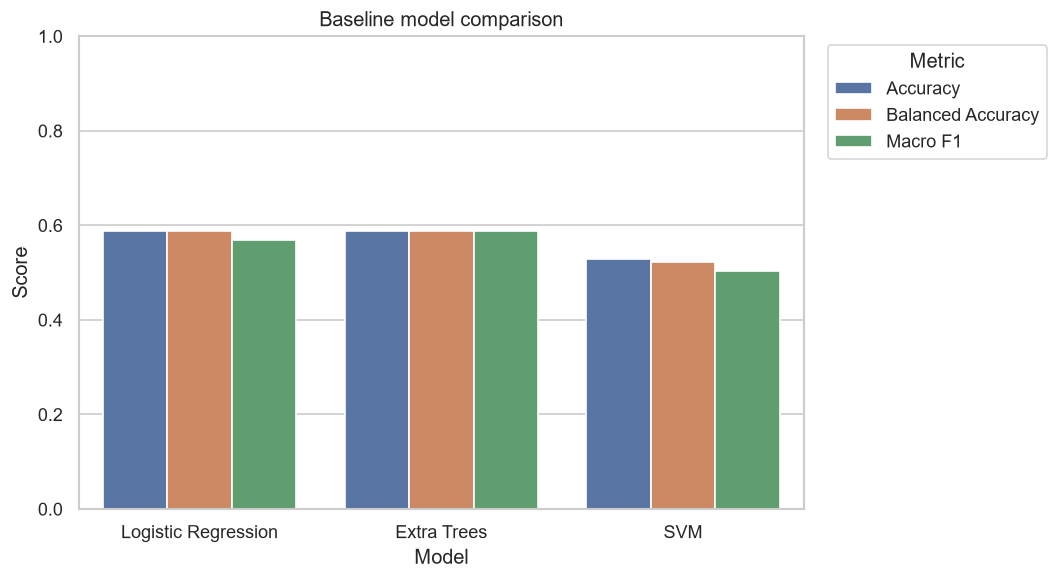

In [10]:
plt.figure(figsize=(9, 5))

plot_results = model_result_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Balanced Accuracy', 'Macro F1'],
    var_name='Metric',
    value_name='Score'
)

sns.barplot(
    data=plot_results,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.ylim(0, 1)
plt.title('Baseline model comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ============================================================
# 7. Extra Trees Hyperparameter Tuning
# ============================================================


In [11]:

extra_trees_pipeline_small = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectKBest(score_func=f_classif, k=50)),
    ('model', ExtraTreesClassifier(
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

small_param_grid = {
    'selector__k': [20, 50, 100, 'all'],
    'model__n_estimators': [300],
    'model__max_features': ['sqrt', 'log2', 0.5],
    'model__min_samples_leaf': [1, 2, 4]
}

small_search = GridSearchCV(
    estimator=extra_trees_pipeline_small,
    param_grid=small_param_grid,
    scoring='balanced_accuracy',
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    ),
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

small_search.fit(X_train, Y_train)

print(f'Best CV Balanced Accuracy:{small_search.best_score_}')
print(f"Best parameters:{small_search.best_params_}")


Best CV Balanced Accuracy:0.5833333333333334
Best parameters:{'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__n_estimators': 300, 'selector__k': 100}


# ============================================================
# 8.Final locked test evaluation for the selected Extra Trees model
# ============================================================


In [12]:

final_predictions = small_search.predict(X_test)

print(f'Final Extra Trees test results')
print(f'Accuracy:{accuracy_score(Y_test, final_predictions)}')
print(f'Balanced Accuracy:{balanced_accuracy_score(Y_test, final_predictions)}')
print('Macro Precision:', precision_score(
    Y_test, final_predictions, average='macro', zero_division=0
))
print('Macro Recall:', recall_score(
    Y_test, final_predictions, average='macro', zero_division=0
))
print('Macro F1:', f1_score(
    Y_test, final_predictions, average='macro', zero_division=0
))


Final Extra Trees test results
Accuracy:0.6470588235294118
Balanced Accuracy:0.6444444444444445
Macro Precision: 0.6583333333333333
Macro Recall: 0.6444444444444445
Macro F1: 0.638095238095238


# ============================================================
# 9.Classification Report
# ============================================================


In [13]:
print(classification_report(
    Y_test,
    final_predictions,
    labels=[1, 2, 3],
    target_names=['Minimal', 'Mild', 'Moderate'],
    zero_division=0
))


              precision    recall  f1-score   support

     Minimal       0.75      0.50      0.60         6
        Mild       0.60      0.60      0.60         5
    Moderate       0.62      0.83      0.71         6

    accuracy                           0.65        17
   macro avg       0.66      0.64      0.64        17
weighted avg       0.66      0.65      0.64        17



# ============================================================
# 10.Confusion Matrix
# ============================================================


Rows = True labels; Columns = Predicted labels
[[3 1 2]
 [1 3 1]
 [0 1 5]]


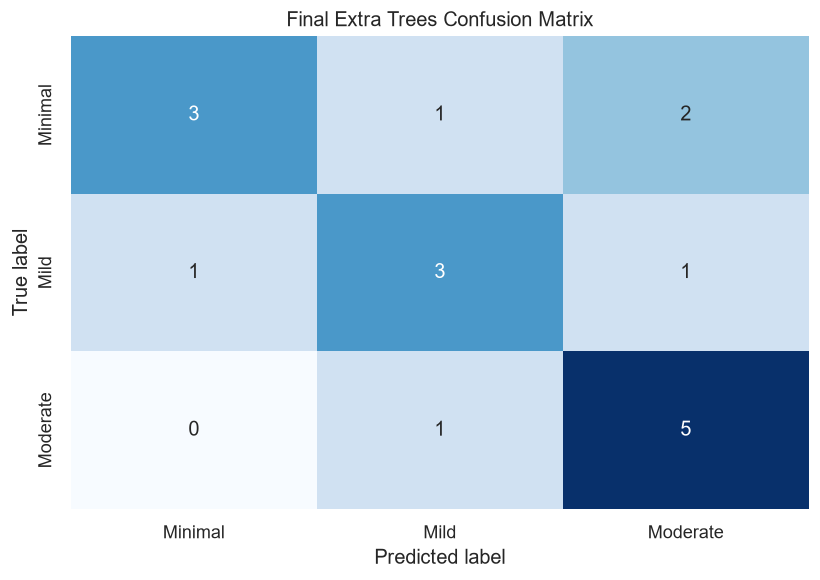

In [14]:
cm = confusion_matrix(
    Y_test,
    final_predictions,
    labels=[1, 2, 3]
)

print('Rows = True labels; Columns = Predicted labels')
print(cm)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Minimal', 'Mild', 'Moderate'],
    yticklabels=['Minimal', 'Mild', 'Moderate']
)
plt.title('Final Extra Trees Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()


# ============================================================
# 11. participant predictions CSV
# ============================================================


In [15]:
prediction_results = final_df.loc[
    X_test.index,
    ['Group & ID', 'Group', 'Gender', 'BDI_II', 'PHQ9']
].copy()

prediction_results['True Label'] = prediction_results['Group'].map({
    1: 'Minimal', 2: 'Mild', 3: 'Moderate'
})

prediction_results['Predicted Group'] = final_predictions
prediction_results['Predicted Label'] = prediction_results['Predicted Group'].map({
    1: 'Minimal', 2: 'Mild', 3: 'Moderate'
})
prediction_results['Correct'] = (
    prediction_results['Group'] == prediction_results['Predicted Group']
)

display(prediction_results)
prediction_results.to_csv('final_participant_predictions.csv', index=False)


,Group & ID,Group,Gender,BDI_II,PHQ9,True Label,Predicted Group,Predicted Label,Correct
54,E2-7,2,Female,15,7,Mild,2,Mild,True
45,E2-23,2,Male,15,7,Mild,2,Mild,True
20,E1-28,1,Male,1,1,Minimal,1,Minimal,True
44,E2-22,2,Male,14,8,Mild,2,Mild,True
19,E1-27,1,Female,2,3,Minimal,3,Moderate,False
71,E3-22,3,Female,24,14,Moderate,3,Moderate,True
7,E1-16,1,Female,12,4,Minimal,2,Mild,False
70,E3-21,3,Male,20,18,Moderate,3,Moderate,True
6,E1-15,1,Female,4,5,Minimal,1,Minimal,True
10,E1-19,1,Male,8,6,Minimal,1,Minimal,True


# ============================================================
# 12.Model Stability Analysis
# ============================================================


In [16]:

selected_model = small_search.best_estimator_

selected_model_stability = cross_validate(
    selected_model,
    X_train,
    Y_train,
    cv=RepeatedStratifiedKFold(
        n_splits=5,
        n_repeats=10,
        random_state=RANDOM_STATE
    ),
    scoring={
        'balanced_accuracy': 'balanced_accuracy',
        'macro_f1': 'f1_macro'
    },
    n_jobs=-1,
    return_train_score=False
)

balanced_values = selected_model_stability['test_balanced_accuracy']
f1_values = selected_model_stability['test_macro_f1']

print('Selected Extra Trees stability')
print(f'\n Balanced Accuracy mean:{balanced_values.mean()}' )
print(f'\n Balanced Accuracy SD:{ balanced_values.std()}')
print(f'\n Balanced Accuracy min:{ balanced_values.min()}')
print(f'\n Balanced Accuracy max:{balanced_values.max()}' )
print()
print(f'\n Macro F1 mean:{ f1_values.mean()}')
print(f'\n Macro F1 SD:{ f1_values.std()}')
print(f'\n Macro F1 min:{ f1_values.min()}')
print(f'\n Macro F1 max:{f1_values.max()}')


Selected Extra Trees stability

 Balanced Accuracy mean:0.5213333333333333

 Balanced Accuracy SD:0.11338430226446693

 Balanced Accuracy min:0.31666666666666665

 Balanced Accuracy max:0.8333333333333334


 Macro F1 mean:0.5058704998704998

 Macro F1 SD:0.11785645165303198

 Macro F1 min:0.3225108225108225

 Macro F1 max:0.8387445887445888
